In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Filter out the Data Analyst job postings in the US
df_DA_US = df[(df['job_title']== 'Data Analyst') & (df['job_country']== 'United States')].copy()

In [3]:
#Create a columne name 'job_posted_month_no' to show the month in number from the job_posted_date 
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [4]:
#Explode the job skills and put it in a new dataframe called df_DA_US_explode
df_DA_US_explode = df_DA_US.explode('job_skills')

In [5]:
#Create a pivot table from the dataframe and name it 'df_DA_US_pivot
df_DA_US_pivot = df_DA_US_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)

#Summarise the number of each column
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

# Next, sort value from high to low by passing the index (not the value) because this is a series
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending = False).index]

#Then we drop a 'Total' row because we don't need it
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

In [8]:
#To see the total job_posted per month
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

#To calculate each skills per total in each month - we use .div instead of normal loop through as usual
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis = 0)

#Change month number to month name
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format = '%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns ='job_posted_month_no')


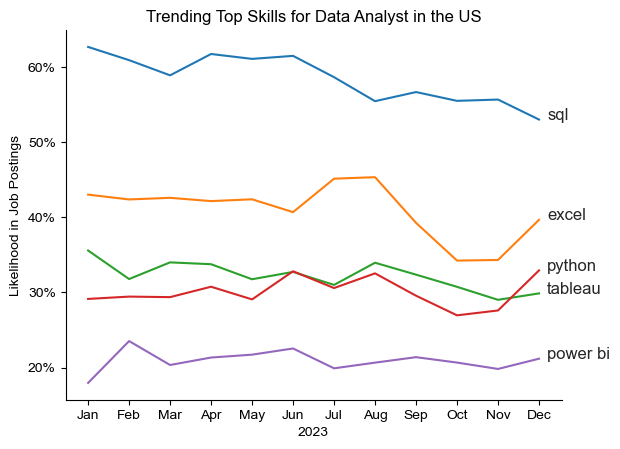

In [9]:
# Select the top 5 skills in each month (.iloc, which is used to select rows and columns by their position (number))
df_plot = df_DA_US_percent.iloc[:, :5]

# Plot line grapth using Seaborn
sns.lineplot(data = df_plot, dashes = False, palette = 'tab10')
sns.set_theme(style = 'ticks')
sns.despine()

#Clean up the graph
plt.title('Trending Top Skills for Data Analyst in the US')
plt.ylabel('Likelihood in Job Postings')
plt.xlabel('2023')
plt.legend().remove()

# Set Y label to %, so first we need to import the percentage format from matplotlib (decimals = 0 means no decimal)
from matplotlib.ticker import PercentFormatter 
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Once remove legend, label what each line is (note: Change from 11 to 11.2 to make the label a little bit farther from the end of the line)
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])